<a href="https://colab.research.google.com/github/LeviJunior21/CienciaDadosDescritiva/blob/main/Laborat%C3%B3rio_de_Regress%C3%A3o_Linear_Simples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Ciência de Dados Preditiva</h1>

<h2>Regressão Linear Simples</h2>


<h3>Aluno: Levi de Lima Pereira Júnior</h3>
<h4>Matrícula: 121210472</h4>

## 1. Preparação do Ambiente

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time


In [ ]:
np.random.seed(42)

# Gerar dados sintéticos
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Adicionar o termo de bias
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Adiciona a coluna de 1s

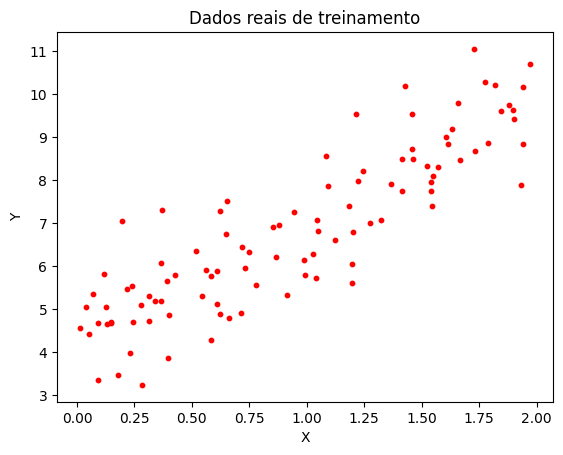

In [ ]:
import matplotlib.pyplot as plt

plt.title("Dados de treino para regressão linear")
plt.scatter(X, y, s=10, color='red')
plt.title("Dados reais de treinamento")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## 2. Função de Custo

In [ ]:
def compute_cost(theta, X, y):
    """
    Calcula a soma dos erros quadráticos.
    Args:
        theta (list): Lista de parâmetros [bias, coeficiente angular].
        X (np.ndarray): Matriz de entrada (com bias incluído).
        y (np.ndarray): Vetor de saídas verdadeiras.
    Returns:
        float: Soma dos erros quadráticos.
    """
    m = len(y)
    cost = 0
    for i in range(m):
        cost += (y[i] - (theta[0] + theta[1] * X[i])) ** 2
    return cost


## 3. Gradiente Descendente

In [ ]:
def gradient_descent(X, y, theta, learning_rate, num_iterations):
    """
    Implementa o gradiente descendente para regressão linear.
    Args:
        X (np.ndarray): Matriz de entrada (com bias incluído).
        y (np.ndarray): Vetor de saídas verdadeiras.
        theta (list): Lista inicial de parâmetros [bias, coeficiente angular].
        learning_rate (float): Taxa de aprendizado.
        num_iterations (int): Número de iterações.
    Returns:
        list, list: Lista final de parâmetros e histórico de custos.
    """
    m = len(y)
    cost_history = []

    for iteration in range(num_iterations):
        gradients = [0, 0]  # Gradientes para bias e coeficiente
        for i in range(m):
            gradients[0] += -2 * (y[i] - (theta[0] + theta[1] * X[i]))
            gradients[1] += -2 * (y[i] - (theta[0] + theta[1] * X[i])) * X[i]

        # Atualização dos parâmetros
        # O sinal negativo informa a direção oposta a onde a maior taxa de variação ocorre, faremos isso para o coficiente linear e angular da reta
        theta[0] -= learning_rate * gradients[0]
        theta[1] -= learning_rate * gradients[1]

        # Salvar o custo para análise
        cost_history.append(compute_cost(theta, X, y))

    return theta, cost_history

Ŷ = 4.215096157546642 + 2.7701133864385734 * X

Bias: 4.215096157546642
Coeficiente angular: 2.7701133864385734


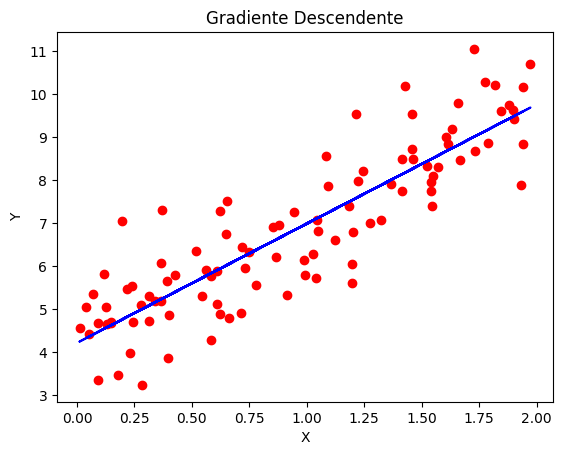

In [ ]:
theta, cost = gradient_descent(X, y, [0, 0], 0.0001, 10000)
y_pred = theta[0] + theta[1] * X

print(f'Ŷ = {theta[0][0]} + {theta[1][0]} * X')
print(f'\nBias: {theta[0][0]}')
print(f'Coeficiente angular: {theta[1][0]}')


plt.scatter(X, y, color="red")
plt.plot(X, y_pred, color="blue")
plt.title("Gradiente Descendente")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

### 3.1 Gradiente Descendente usando while

In [ ]:
def gradient_RSS(X, y, w0, w1):
    lost_bias = 0
    lost_coef_angular = 0

    for i in range(len(X)):
        lost_bias += y[i] - (w0 + w1 * X[i])
        lost_coef_angular += (y[i] - (w0 + w1 * X[i])) * X[i]

    norma = np.sqrt((-2 * lost_bias) ** 2 + (-2 * lost_coef_angular) ** 2)

    return norma

In [ ]:
def gradient_descent_while(X, y, theta, learning_rate, erro):
    m = len(y)
    cost_history = []

    while (gradient_RSS(X, y, theta[0], theta[1]) >= erro):
        gradients = [0, 0]
        for i in range(m):
            gradients[0] += (y[i] - (theta[0] + theta[1] * X[i]))
            gradients[1] += (y[i] - (theta[0] + theta[1] * X[i])) * X[i]

        theta[0] -= learning_rate * (-2) * gradients[0]
        theta[1] -= learning_rate * (-2) * gradients[1]

        cost_history.append(compute_cost(theta, X, y))

    return theta, cost_history

In [ ]:
learning_rate = 0.0001
error = 0.000001
theta_while, cost_while = gradient_descent_while(X, y, [0, 0], learning_rate, error)
y_pred_reg_while = theta_while[0] + theta_while[1] * X

print("Regressão Linear Simples com while:\n")
print(f'Ŷ = {theta_while[0][0]} + {theta_while[1][0]} * X')

Regressão Linear Simples com while:

Ŷ = 4.215096135530789 + 2.770113405877379 * X


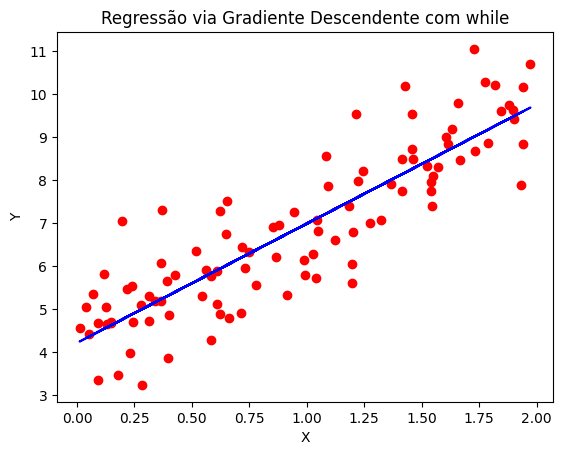

In [ ]:
plt.scatter(X, y, color="red")
plt.plot(X, y_pred_reg_while, color="blue")
plt.title("Regressão via Gradiente Descendente com while")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# 4. Equações Normais

In [ ]:
def normal_equation(X, y):
    """
    Resolve os parâmetros da regressão linear usando as Equações Normais.
    Args:
        X (np.ndarray): Matriz de entrada (com bias incluído).
        y (np.ndarray): Vetor de saídas verdadeiras.
    Returns:
        list: Lista de parâmetros [bias, coeficiente].
    """

    media_x = np.average(X)
    media_y = np.average(y)

    numerador = 0
    denominador = 0

    for i in range(len(X)):
        numerador += (X[i] - media_x) * (y[i] - media_y)
        denominador += (X[i] - media_x) ** 2

    w1 = numerador / denominador
    w0 = media_y - w1 * media_x

    return [w0, w1]

Ŷ = 4.215096157546746 + 2.770113386438485 * X


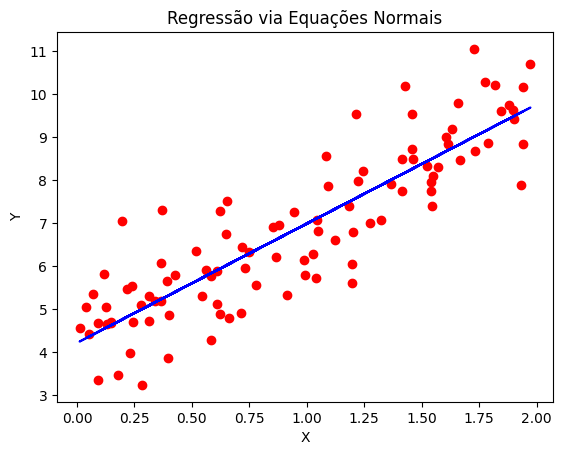

In [ ]:
theta = normal_equation(X, y)

y_pred_normal = theta[0] + theta[1] * X
print(f'Ŷ = {theta[0][0]} + {theta[1][0]} * X')

plt.scatter(X, y, color="red")
plt.plot(X, y_pred_normal, color="blue")
plt.title("Regressão via Equações Normais")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## Questões:

### 1. Meça o tempo de execução de ambas as abordagens.


In [ ]:
import time

learning_rate = 0.0001
iteracoes = 10000
tempo_inicio_gradient = time.perf_counter()
theta_grad, cost_grad = gradient_descent(X, y, [0, 0], learning_rate, iteracoes)
tempo_fim_gradient = time.perf_counter()
print("Para a Regressão Linear Simples:\n")
tempo_gradient = tempo_fim_gradient - tempo_inicio_gradient
print(f'Tempo de execução do gradiente descendente para {iteracoes} iterações a uma taxa de aprendizado de {learning_rate}: {tempo_gradient}')


tempo_inicio_normal = time.perf_counter()
theta_norm = normal_equation(X, y)
tempo_fim_normal = time.perf_counter()
print("\n\nPara Equações Normais:\n")
tempo_normal = tempo_fim_normal - tempo_inicio_normal
print(f'Tempo de execução da equações normais: {tempo_normal}')

Para a Regressão Linear Simples:

Tempo de execução do gradiente descendente para 10000 iterações a uma taxa de aprendizado de 0.0001: 17.541740480000044


Para Equações Normais:

Tempo de execução da equações normais: 0.0010075449999931152


### 2. Analise e visualize a convergência do gradiente descendente

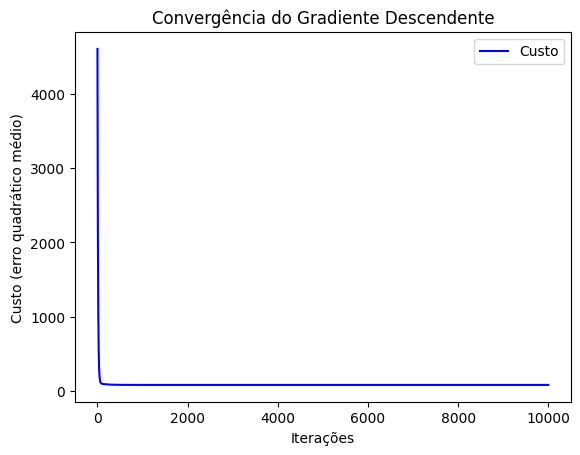

In [ ]:
def plot_cost_history(cost_history):
    plt.plot(range(len(cost_history)), cost_history, color="blue", label="Custo")
    plt.title("Convergência do Gradiente Descendente")
    plt.xlabel("Iterações")
    plt.ylabel("Custo (erro quadrático médio)")
    plt.legend()
    plt.show()

plot_cost_history(cost)

### 3. Compare os parâmetros obtidos por ambas as abordagens.

Para a Regressão Linear Simples:
Ŷ = 4.215096157546642 + 2.7701133864385734 * X

- Bias: 4.215096157546642
- Coeficiente angular: 2.7701133864385734


Para Equações Normais:
Ŷ = 4.215096157546746 + 2.770113386438485 * X

- Bias: 4.215096157546746
- Coeficiente angular: 2.770113386438485




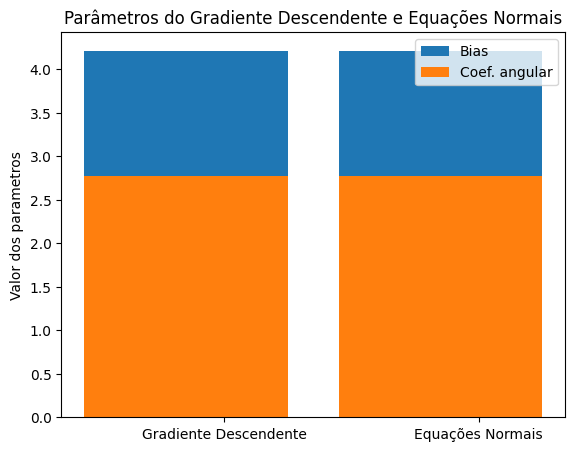

In [ ]:
bias_grad = theta_grad[0][0]
coef_ang_grad = theta_grad[1][0]
print("Para a Regressão Linear Simples:")
print(f'Ŷ = {bias_grad} + {coef_ang_grad} * X')
print(f'\n- Bias: {bias_grad}')
print(f'- Coeficiente angular: {coef_ang_grad}')

bias_norm = theta_norm[0][0]
coef_ang_norm = theta_norm[1][0]
print("\n\nPara Equações Normais:")
print(f'Ŷ = {bias_norm} + {coef_ang_norm} * X')
print(f'\n- Bias: {bias_norm}')
print(f'- Coeficiente angular: {coef_ang_norm}')


print("\n")

width = 0.3
x = np.arange(2)
fix, ax = plt.subplots(figsize=(6.5, 5), dpi=100)
ax.bar(x - width/2, [bias_grad, bias_norm], label="Bias")
ax.bar(x - width/2, [coef_ang_grad, coef_ang_norm], label="Coef. angular")
ax.set_title("Parâmetros do Gradiente Descendente e Equações Normais")
ax.set_ylabel("Valor dos parametros")
ax.set_xticks(x)
ax.set_xticklabels(['Gradiente Descendente', 'Equações Normais'])
ax.legend()

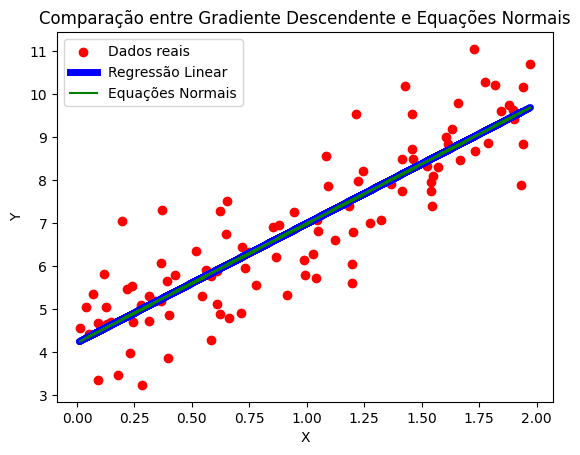

In [ ]:

plt.scatter(X, y, color="red", label="Dados reais")
plt.plot(X, y_pred, color="blue", label="Regressão Linear", linewidth=5)
plt.plot(X, y_pred_normal, color="green", label="Equações Normais")
plt.title("Comparação entre Gradiente Descendente e Equações Normais")
plt.ylabel("Y")
plt.xlabel("X")
plt.legend()
plt.show()

### 4. Discussão:
- Quais são as vantagens e desvantagens de cada abordagem?
- Em quais cenários o gradiente descendente seria preferível?
- Em quais cenários as equações normais seriam mais adequadas?

### Sobre o uso de assistência de IA

De forma geral, recomendo que a atividade seja feita sem o uso de IA, pois acredito que mesmo podendo usar calculadoras para fazer contas, ainda precisamos saber fazer as contas. Ao mesmo tempo, não é proibido usar, contanto que sejam seguidas as diretrizes abaixo:

**Usos focados no aprendizado:**
- Buscar explicações de conceitos específicos (como gradiente descendente ou MSE).
- Verificar erros no código ou receber sugestões para partes já desenvolvidas.
- Obter exemplos simples de lógica de programação.

**O que não é permitido:**

- Solicitar a solução completa da atividade.
- Copiar trechos de código fornecidos pela IA sem entendê-los.

**Se decidir usar a ajuda da IA, inclua no relatório da atividade:**

- Liste as perguntas feitas à IA e descreva como isso os ajudou.
- Exemplo de resposta esperada: "Perguntei à IA como calcular o gradiente para regressão linear. Ela explicou a fórmula, o que ajudou a estruturar minha função gradient_descent."
- Reflexão sobre o impacto do uso da IA: Responda como o uso da IA contribuiu para seu aprendizado nesta atividade.

<h1>Quais são as vantagens e desvantagens de cada abordagem?</h1>

## Gradiente Descendente:

### Vantagens
- A vantagem é que no Gradiente Descendente é possível controlar a taxa de aprendizagem do modelo.
- É usado também para funções não lineares.
- Funciona bem em datasets grandes.

### Desvantagens
- As desvantagens da abordagem via Gradiente Descendente é que a sua convergência é lenta, pois o método usado é iterativo.
- Se o tamanho do passo não for bem ajustado, ou seja, o número de iterações for menor que o ideal, então o modelo não será bom suficiente, sendo assim, terão maiores perdas.
- A taxa de aprendizagem pode ser um problema, pois caso usemos uma taxa de aprendizagem inadequada, talvez o modelo nunca converja ou demore muito para convergir, ele é sensível a taxa de aprendizado.
- Outro fator, é que se a limiar da perda for passado errado, por exemplo menor ou igual a 0, então ele nunca irá convergir, pois o gradiente sempre terá um valor maior que 0, ou seja, sempre haverá perda.

## Equações Normais:

### Vantagens
- A vantagem da abordagem via Equações Normais é o tempo de execução, sua execução é mais rápida porque utiliza multiplicação de matrizes, e o computador computa isso de forma mais rápida do que a iterativa que por sua vez usa o Gradiente Descendente.
- A abordagem da Equações Normais é fácil de entender, é direto e o código é bem menor se comparado ao algoritmo do Gradiente Descendente.
- Equações normais funciona melhor em datasets pequenos.

### Desvantagens
- Exige mais memória que o Gradiente Descendente, pois para matrizes muito grandes ele torna-se muito caro computacionalmente.

# Em quais cenários o gradiente descendente seria preferível?

- O Gradiente Descendente será preferivel em cenários onde o número de dados é muito grande, pois o método é iterativo.

- Quando temos modelos não lineares. No nosso caso, usamos a função de ativação linear porque assumimos que o mundo funciona linearmente, mas quando propomos que o mundo não funciona de maneira linear, podemos usar outras funções de ativação para o modelo.

# Em quais cenários as equações normais seriam mais adequadas?
- A Equações Normais pode ser usada quando o conjunto de dados é pequeno.
- É usada em problemas simples de Regressão Linear.
- E ela é usada também em problemas de baixa dimensionalidade.